In [3]:
import sys
import os


from tqdm import tqdm
import time


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


sys.path.append(os.path.abspath(".."))
from package.SingleCharTokenizer import * 
from package.TextDataset import * 
from package.GPT import * 
from package.Engine import * 


import matplotlib.pyplot as plt


from IPython.display import clear_output, display

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
sliding_windows = 0.

context_window = 128
batch_size = 32

d_emb = 512
nb_heads = 4
d_k = d_emb // nb_heads

nb_layers = 8

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#device = torch.device("cpu")
print(device)

mps


In [12]:
tokenizer = SingleCharTokenizer()
tokens = torch.tensor(tokenizer.load_tokens("../tokens_sc.tok"))
print(tokens.shape)


vocab_size = tokenizer.vocab_size
print("vocab_size : " , vocab_size)

dataset = TextDataset(tokens,context_window=context_window,sliding_windows=sliding_windows)
print("dataset_size : " ,len(dataset))


loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers = 2
)


torch.Size([11473626])
vocab_size :  65
dataset_size :  11473499


In [13]:
gpt = GPT(vocab_size=vocab_size, context_window=context_window, d_emb=d_emb,nb_layers=nb_layers,nb_heads=nb_heads).to(device)
gpt.architecture()

PARAMETERS :
embedding.E.weight: mps:0 torch.Size([65, 512]) 33280
embedding.P.weight: mps:0 torch.Size([128, 512]) 65536
transformer_blocks.0.norm1.weight: mps:0 torch.Size([512]) 512
transformer_blocks.0.norm1.bias: mps:0 torch.Size([512]) 512
transformer_blocks.0.norm2.weight: mps:0 torch.Size([512]) 512
transformer_blocks.0.norm2.bias: mps:0 torch.Size([512]) 512
transformer_blocks.0.attention.Wq.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.attention.Wk.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.attention.Wv.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.attention.Wo.weight: mps:0 torch.Size([512, 512]) 262144
transformer_blocks.0.feed_forward.NN.0.weight: mps:0 torch.Size([1536, 512]) 786432
transformer_blocks.0.feed_forward.NN.0.bias: mps:0 torch.Size([1536]) 1536
transformer_blocks.0.feed_forward.NN.2.weight: mps:0 torch.Size([512, 1536]) 786432
transformer_blocks.0.feed_forward.NN.2.bias: mps:0 torch.Size([512]) 512
tr

In [14]:
engine = Engine(gpt,tokenizer,device)
print(len(iter(loader)))

358546


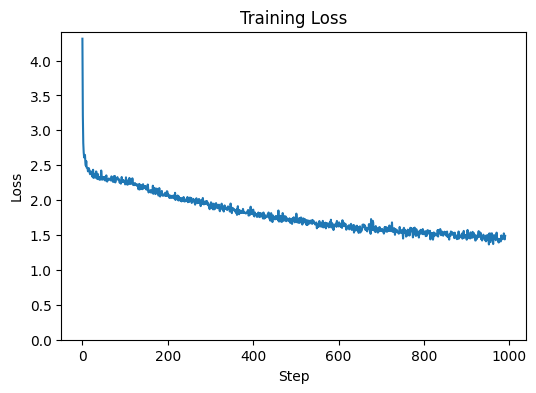

|----------------------------------------| 0/1 [853.1s<0.0s, 0.0 it/s]
|███████████████████████████████████████-| 990/1000 [853.1s<8.6s, 1.2 it/s]
je pense que le courant ; la marche eur le 


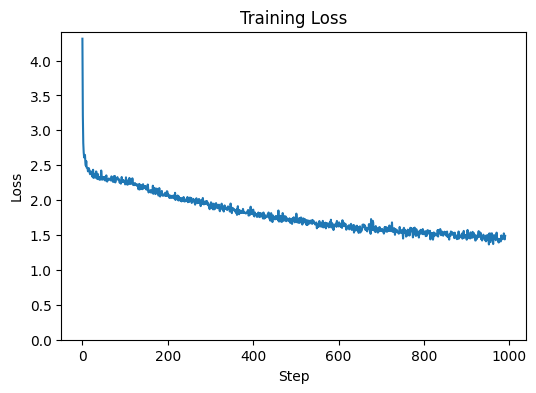

In [15]:
engine.train(loader,1,2000,1000,print_frequency=10)
engine.save_model("training_historic/final.w")

[4.313239097595215, 3.2149887084960938, 2.817561626434326, 2.6835994720458984, 2.612518548965454, 2.608597755432129, 2.648479461669922, 2.531351327896118, 2.493699550628662, 2.5588035583496094, 2.4646496772766113, 2.4628772735595703, 2.4582154750823975, 2.412613868713379, 2.4317359924316406, 2.4579901695251465, 2.438493490219116, 2.3924484252929688, 2.3709888458251953, 2.3803980350494385, 2.4125280380249023, 2.372514247894287, 2.389163017272949, 2.3381741046905518, 2.375253200531006, 2.4351584911346436, 2.3186419010162354, 2.362981081008911, 2.3622193336486816, 2.3780298233032227, 2.321646213531494, 2.343388795852661, 2.4115872383117676, 2.40110445022583, 2.3075978755950928, 2.330303907394409, 2.374809741973877, 2.29990291595459, 2.3333840370178223, 2.3161468505859375, 2.2999534606933594, 2.290109634399414, 2.3272857666015625, 2.32170033454895, 2.4246602058410645, 2.358635187149048, 2.2926788330078125, 2.296940326690674, 2.2997307777404785, 2.3287196159362793, 2.3248918056488037, 2.333